INFO:purepyindi2.transports:Connected to localhost:7624


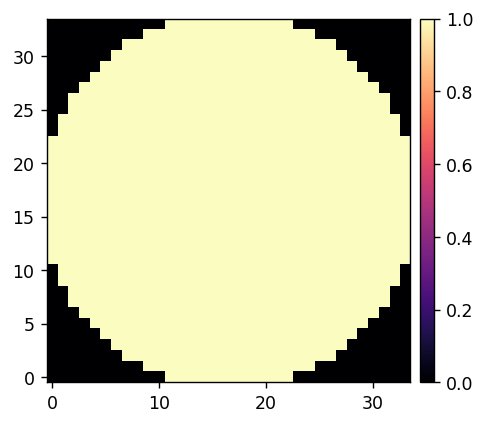

In [9]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoobscc


from scoobscc.math_module import xp, xcipy, ensure_np_array
from scoobscc import utils, telem, dm
from scoobscc import scc
import scoobscc.scoob_interface as scoobi

import scoobpy


from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307 / 2 # divide by 2 for bin 1 

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

## Make Experiment Directory

In [10]:
today = int(datetime.today().strftime('%Y%m%d'))
data_path = str(scoobscc.path)[:-9] + '/data_exp'

exp_path = data_path + f'/{today}_scc_dig_mono'
telem.make_dir(exp_path)

Directory '/home/derbyk/src/scoob-scc/data_exp/20250610_scc_dig_mono' already exists.


## Initialize ImageStreams

In [11]:
reload(scoobi)
camsci_channel = 'camsci'
dm_ho_channel = 'dm00disp03'

camsci_stream = ImageStream(camsci_channel)
dm_ho_stream = ImageStream(dm_ho_channel)

## Camera Settings

In [12]:
reload(scoobi)
xc, yc = (5656, 2619)
ncamsci = 512

scoobi.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel, bin_mode=1)
time.sleep(1)
scoobi.set_cam_exp_time(500e-6, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_blacklevel(4, client0, cam_name=camsci_channel)

Set camsci ROI.
Set the camsci exposure time to 5.00e-04s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 4.0


## Get Dark Frame

In [5]:
reload(scoobi)
scoobi.move_block_in(client0)

INFO:utils:Got semaphore index 1.


{'texp': 0.000500000023748726, 'gain': 120.0, 'atten': 0.0}


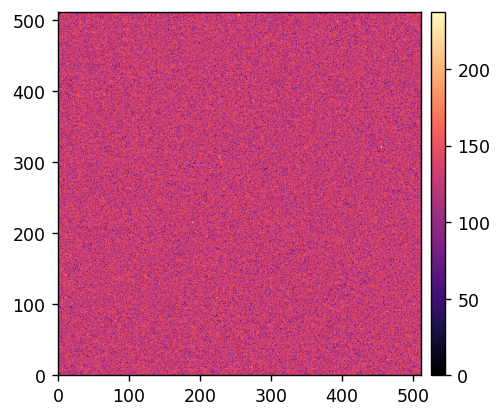

In [13]:
reload(scoobi)
dark_frame = scoobi.snap(camsci_stream, 500)
dark_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
dark_params.update({'atten':0.0})
print(dark_params)

time.sleep(1)
scoobi.move_block_out(client0)

utils.imshow([dark_frame])

In [14]:
hdu = fits.PrimaryHDU(data=dark_frame)
hdr = hdu.header
hdr['TEXP'] = dark_params['texp']
hdr['GAIN'] = dark_params['gain']
hdr['ATTEN'] = dark_params['atten']

hdu.writeto(exp_path + '/dark_frame.fits', overwrite=True)

## Get Reference PSF


In [70]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_x_pos', val=-100)

In [71]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_y_pos', val=-100)

In [74]:
reload(scoobi)
scoobi.set_fib_atten(33, client)

Set the fiber attenuation to 33.0


{'texp': 0.000500000023748726, 'gain': 120.0, 'atten': 33.0, 'Iref': 26130.48}


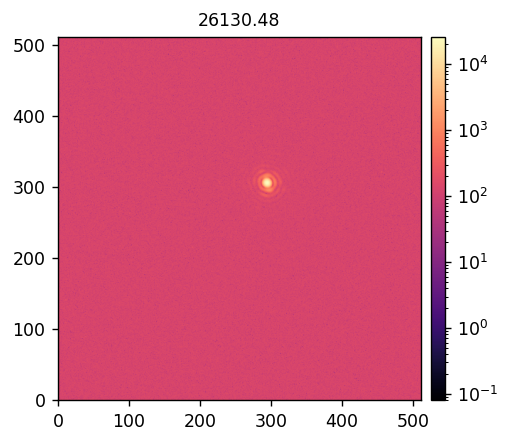

In [75]:
reload(scoobi)
ref_psf = scoobi.snap(camsci_stream, 200)
Iref = np.max(ref_psf)
ref_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
ref_params.update({'atten':33.0})
ref_params.update({'Iref': Iref})
print(ref_params)

utils.imshow([ref_psf], titles=[f'{Iref:.2f}'], norms=[LogNorm()])

In [76]:
hdu = fits.PrimaryHDU(data=ref_psf)
hdr = hdu.header
hdr['TEXP'] = ref_params['texp']
hdr['GAIN'] = ref_params['gain']
hdr['ATTEN'] = ref_params['atten']

hdu.writeto(exp_path + '/ref_psf.fits', overwrite=True)

In [ ]:
reload(scoobi)
scoobi.set_fib_atten(5, client)

Set the fiber attenuation to 5.0


In [164]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_x_pos', val=1)

In [173]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_y_pos', val=1)

## Waffle For Centering

In [174]:
im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':5.0})
print(im_params)

{'texp': 0.000500000023748726, 'gain': 120.0, 'atten': 5.0}


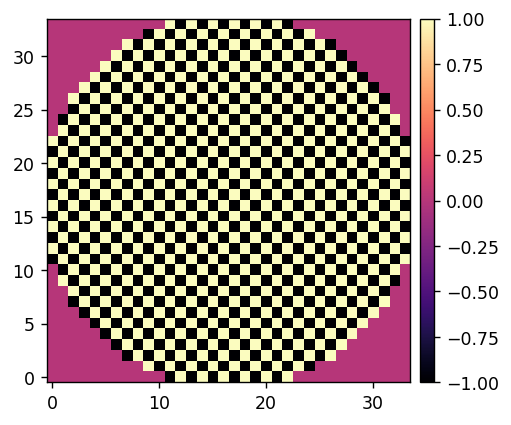

In [175]:
reload(dm)
waffle_command = ensure_np_array(dm.make_fourier_command(x_cpa=17, y_cpa=17)) * dm_mask
utils.imshow([waffle_command])

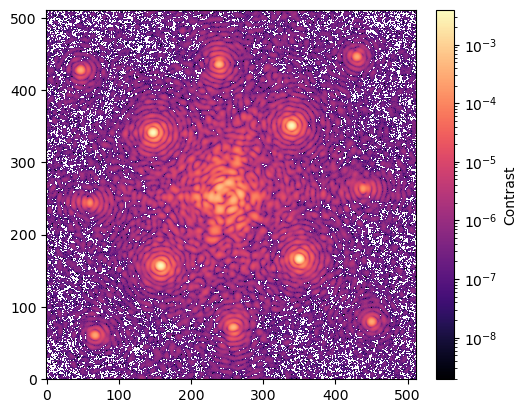

In [176]:
reload(scoobi)
scoobi.set_dm(dm_ho_stream, 50e-9 * waffle_command)
waffle_im = scoobi.snap(camsci_stream, 100, dark_frame, im_params, ref_params)

plt.figure()
plt.imshow(waffle_im, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')

In [177]:
scoobi.zero_dm(dm_ho_stream)

Centroids:
 [[158.28541376 156.26225707]
 [147.8259772  340.64660179]
 [339.40945865 350.08249477]
 [350.15987704 165.76942145]
 [158.28541376 156.26225707]]


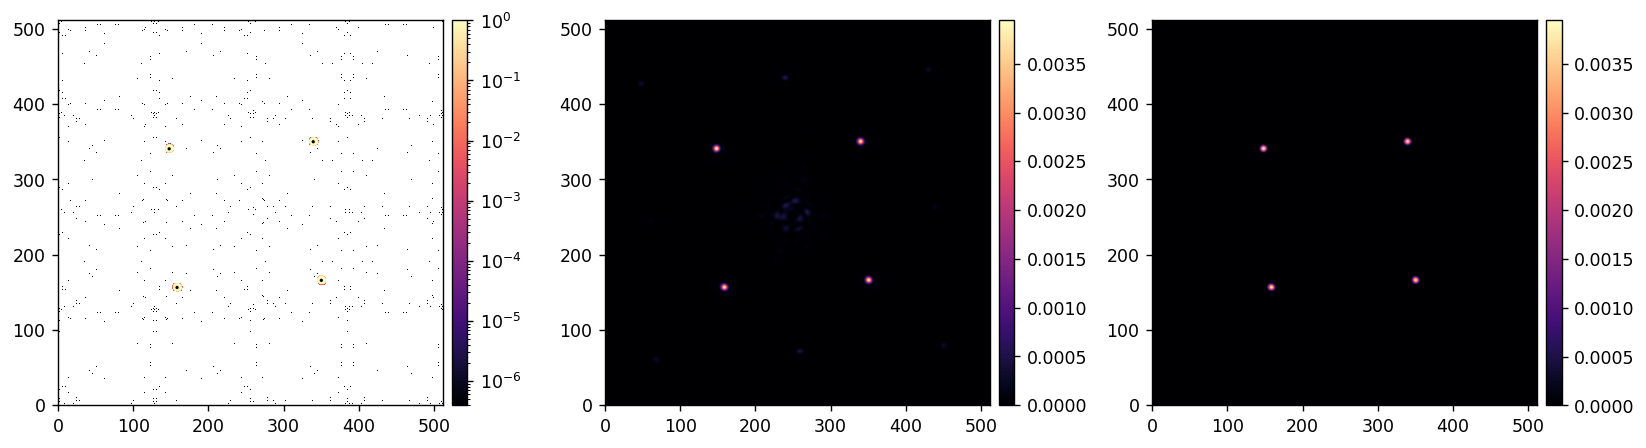

Angle:  86.93972895495153
Measured center in X:  248.93086453980342
Measured center in Y:  253.26165230223083
Required shift in X:  7.0
Required shift in Y:  3.0


In [178]:
reload(utils)

xshift, yshift, angle = utils.measure_waffle_center_and_angle(
    xp.array(waffle_im), 
    camsci_pxscl_lamDc, 
    im_thresh=5e-4, 
    r_thresh_min=16,
    r_thresh_max=25,
)

## Create Control Mask

In [179]:
reload(utils)
iwa = 3
owa = 10
rotation = 0
control_mask = ensure_np_array( utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=-xshift,
    y_shift=-yshift,
    rotation=rotation,
))

In [ ]:
scoobi.set_fib_atten(8, client)

Set the fiber attenuation to 8.0


{'texp': 0.000500000023748726, 'gain': 120.0, 'atten': 8.0}


Text(0.5, 0.98, 'Control Region Contrast: 1.59e-05')

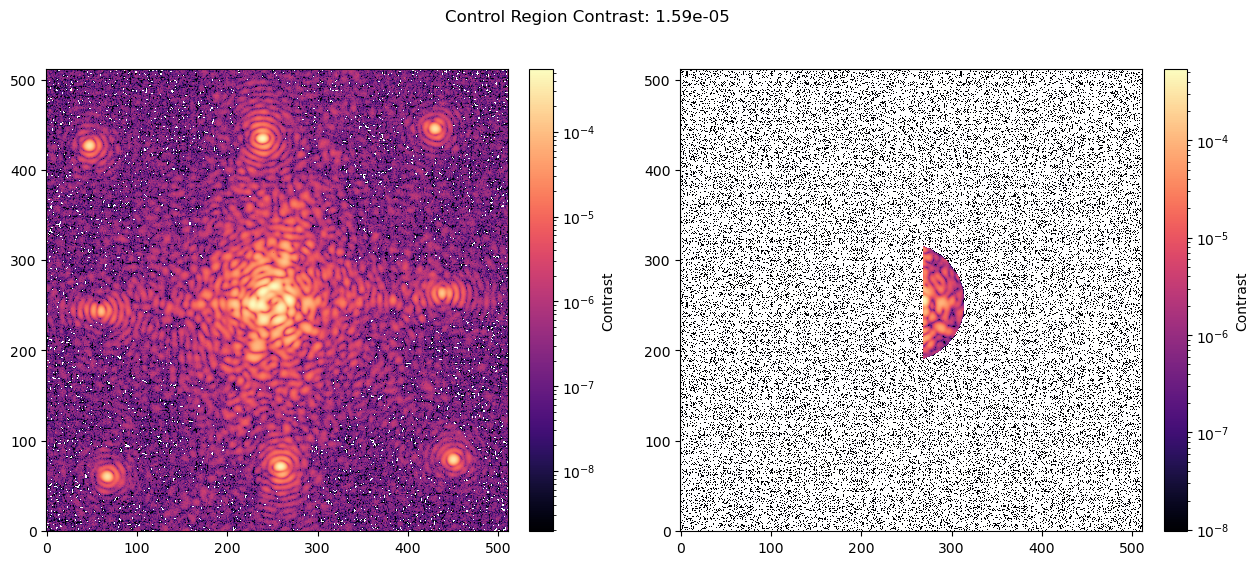

In [223]:
scoobi.zero_dm(dm_ho_stream)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':8.0})
print(im_params)

ref_coro_im = scoobi.snap(camsci_stream, 200, dark_frame, im_params, ref_params)
ref_coro_im[ref_coro_im < 0] = 0

plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(ref_coro_im, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.subplot(122)
plt.imshow(ref_coro_im * control_mask, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.suptitle(f'Control Region Contrast: {np.mean(ref_coro_im[control_mask]):.2e}')

## Create DM Control Modes

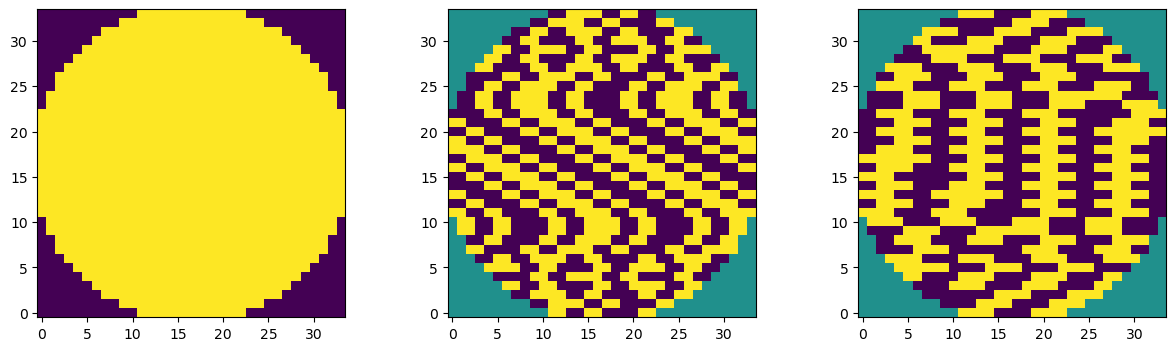

In [224]:
dm_modes = ensure_np_array(dm.create_hadamard_modes(xp.array(dm_mask))) 

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(dm_modes[0])
plt.subplot(132)
plt.imshow(dm_modes[10])
plt.subplot(133)
plt.imshow(dm_modes[100])

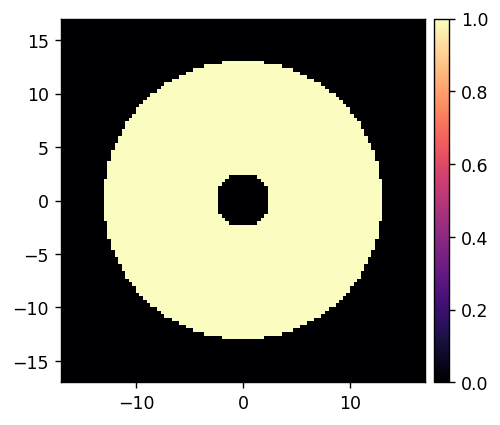

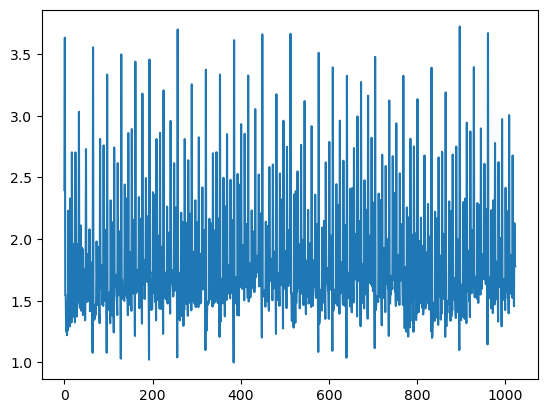

In [225]:
reload(scc)
scale_factors = scc.compute_hadamard_scale_factors(xp.array(dm_modes), scale_exp=1/5, scale_thresh=4, oversamp=3, plot=True)

## Calibrate Jacobian

In [226]:
reload(utils)
reload(scc)

scoobi.zero_dm(dm_ho_stream)

ims_mod, ims_unmod = scc.get_calibration_cubes(INDIclient=client,
                                            camsci_stream=camsci_stream, 
                                            dm_stream=dm_ho_stream, 
                                            control_mask=control_mask, 
                                            calibration_amplitude=6e-9, 
                                            calibration_modes=dm_modes,
                                            im_params=im_params,
                                            ref_psf_params=ref_params, 
                                            dark_frame=dark_frame,
                                            NFRAMES=25,
                                            delay=0.01,
                                            scale_factors=scale_factors,)

Begin Sussy Jacobian Calibration...
Finished taking modulated images, moving stagepiezo...7s


Text(0.5, 1.0, 'Difference')

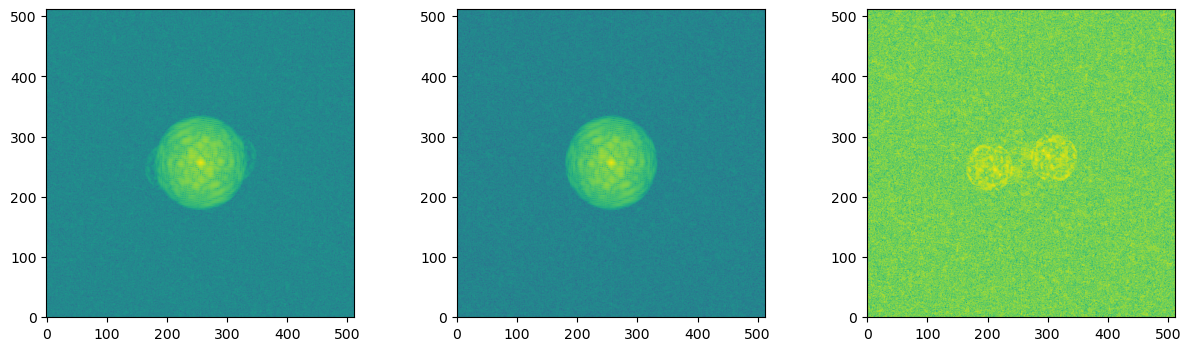

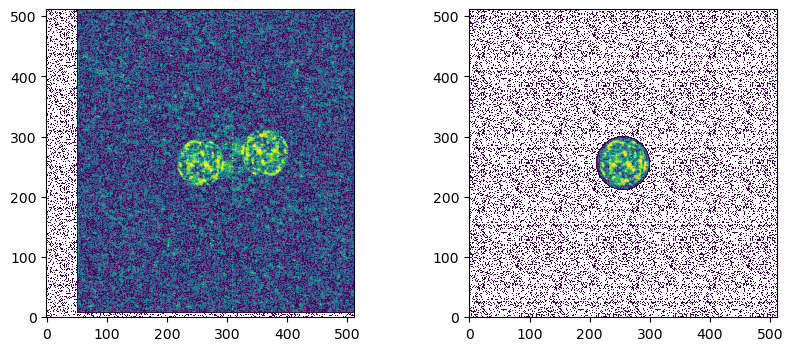

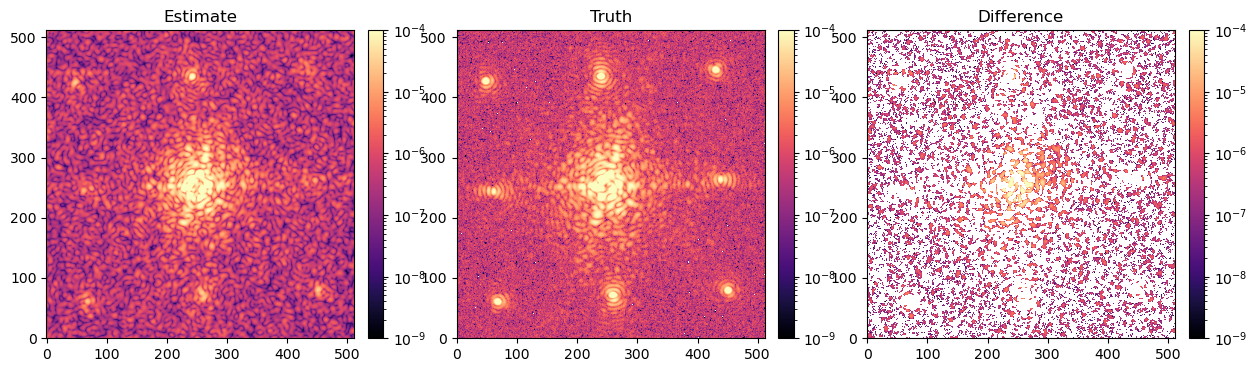

In [217]:
image_mod = xp.asarray(ims_mod[:, :, 0, 0])
image_unmod = xp.asarray(ims_unmod[:, :, 0, 0])

fft_mod = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(image_mod), norm='ortho'))
fft_unmod = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(image_unmod), norm='ortho'))
fft_diff = fft_mod - fft_unmod

fft_shifted = xcipy.ndimage.shift(fft_diff, (8, 53))

x, y = xp.meshgrid(xp.linspace(-1, 1, fft_shifted.shape[0]), xp.linspace(-1, 1, fft_shifted.shape[0]))
r = xp.sqrt(x ** 2 + y ** 2)
mask = r < 0.17

fft_masked = fft_shifted * mask

estimate = xp.fft.ifftshift(xp.fft.fft2(xp.fft.fftshift(fft_masked), norm='ortho'))

estimate *= np.sqrt(image_unmod.max()) / estimate.max()


plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(xp.abs(fft_mod).get(), norm='log')
plt.subplot(132)
plt.imshow(xp.abs(fft_unmod).get(), norm='log')
plt.subplot(133)
plt.imshow(xp.abs(fft_diff).get(), norm='log')


plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(xp.abs(fft_shifted).get(), norm='log', vmin=1e-6, vmax=5e-6)
plt.subplot(122)
plt.imshow(xp.abs(fft_masked).get(), norm='log', vmin=1e-6, vmax=5e-6)


plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(xp.abs(estimate).get() ** 2, cmap='magma', norm='log', vmin=1e-9, vmax=1e-4)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Estimate')
plt.subplot(132)
plt.imshow(image_unmod.get(), cmap='magma', norm='log', vmin=1e-9, vmax=1e-4)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Truth')
plt.subplot(133)
plt.imshow(xp.abs(estimate).get() ** 2 - image_unmod.get(), cmap='magma', norm='log', vmin=1e-9, vmax=1e-4)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Difference')

In [ ]:
reload(utils)
reload(scc)

scoobi.zero_dm(dm_ho_stream)

jacobian, jacobian_full = scc.calc_jacobian(ims_mod=ims_mod,
                                            ims_unmod=ims_unmod,
                                            INDIclient=client,
                                            camsci_stream=camsci_stream, 
                                            dm_stream=dm_ho_stream, 
                                            control_mask=control_mask, 
                                            calibration_amplitude=6e-9, 
                                            calibration_modes=dm_modes,
                                            scc_reference=None,
                                            shift=(8, 53),
                                            diam_window=0.17,
                                            scale_factors=scale_factors, 
                                            return_full_response=True)

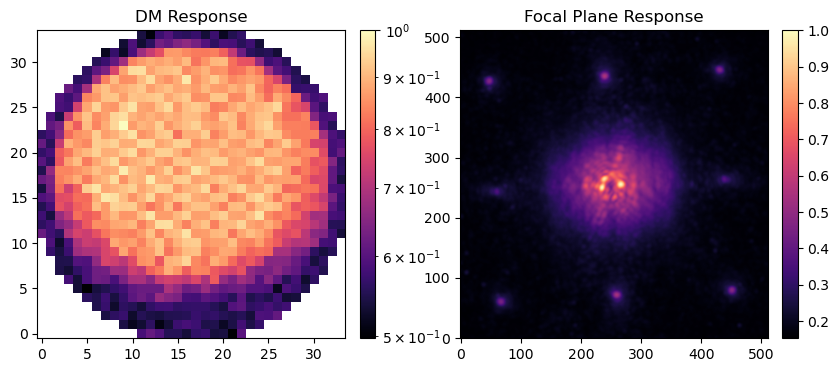

In [234]:
j = np.zeros((int(jacobian.shape[0] / 2), jacobian.shape[1]), dtype='complex128')
j.real = jacobian[::2, :].get()
j.imag = jacobian[1::2, :].get()

jf = np.zeros((int(jacobian_full.shape[0] / 2), jacobian_full.shape[1]), dtype='complex128')
jf.real = jacobian_full[::2, :].get()
jf.imag = jacobian_full[1::2, :].get()

dm_response_map = np.sqrt(np.mean(np.abs(j.dot(dm_modes.reshape(dm_modes.shape[0], -2))), axis=0))
dm_response_map = dm_response_map.reshape(34, 34) / np.max(dm_response_map)

fp_response_map = np.sqrt(np.mean(np.abs(jf), axis=1)).reshape(512, 512)
fp_response_map /= np.max(fp_response_map)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.title('DM Response')
plt.imshow(dm_response_map, cmap='magma', norm='log')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(122)
plt.title('Focal Plane Response')
plt.imshow(fp_response_map, cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04)

In [236]:
cmTI = utils.TikhonovInverse(jacobian, rcond=1e-2)
cm20 = utils.beta_reg(jacobian, -2)
cm25 = utils.beta_reg(jacobian, -2.5)
cm30 = utils.beta_reg(jacobian, -3)
cm35 = utils.beta_reg(jacobian, -3.5)
cm40 = utils.beta_reg(jacobian, -4)
cm45 = utils.beta_reg(jacobian, -4.5)
cm50 = utils.beta_reg(jacobian, -5)

In [312]:
scoobi.set_cam_exp_time(10e-3, client0, cam_name=camsci_channel)

Set the camsci exposure time to 1.00e-02s


In [ ]:
scoobi.set_fib_atten(0, client)

In [313]:

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten' : 0.0})
print(im_params)

{'texp': 0.00999999977648258, 'gain': 120.0, 'atten': 0.0}


In [300]:
scoobi.zero_dm(dm_ho_stream)

data = {
    'images_mod'   : [],
    'images_unmod' : [],
    'commands'     : [],
    'estimate'     : [],
    'image_params' : [],
    'pixelscale'   : camsci_pxscl_lamDc,
    'control_mask' : control_mask, 
}

Running SCC...
	Iteration 1 / 5
Pinhole is blocked, moving stagepiezo...
Taking modulated image...
Finished taking modulated image, moving stagepiezo...
Taking unmodulated image...


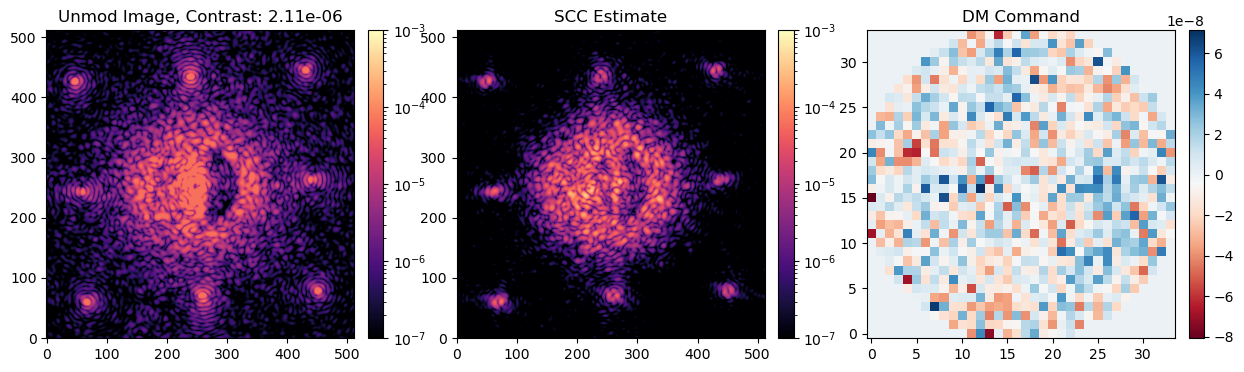

	Iteration 2 / 5
Pinhole is blocked, moving stagepiezo...
Taking modulated image...
Finished taking modulated image, moving stagepiezo...
Taking unmodulated image...


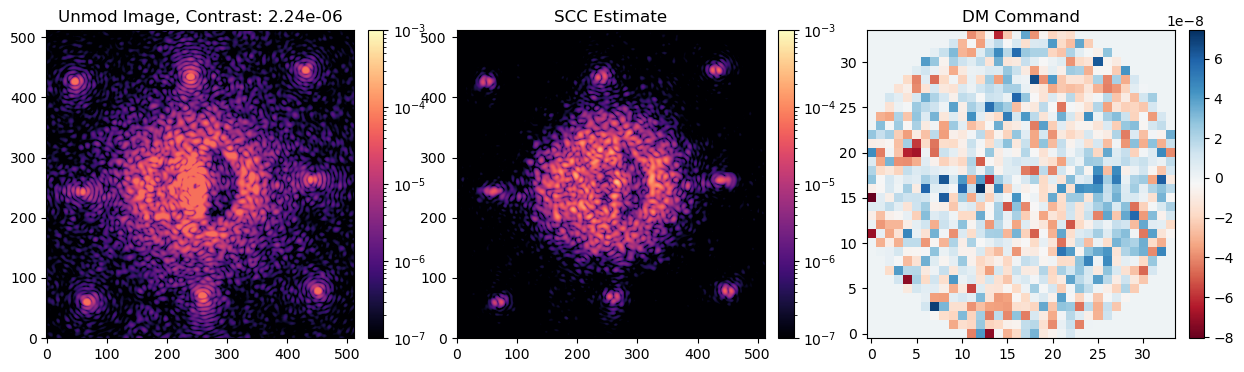

	Iteration 3 / 5
Pinhole is blocked, moving stagepiezo...
Taking modulated image...
Finished taking modulated image, moving stagepiezo...
Taking unmodulated image...


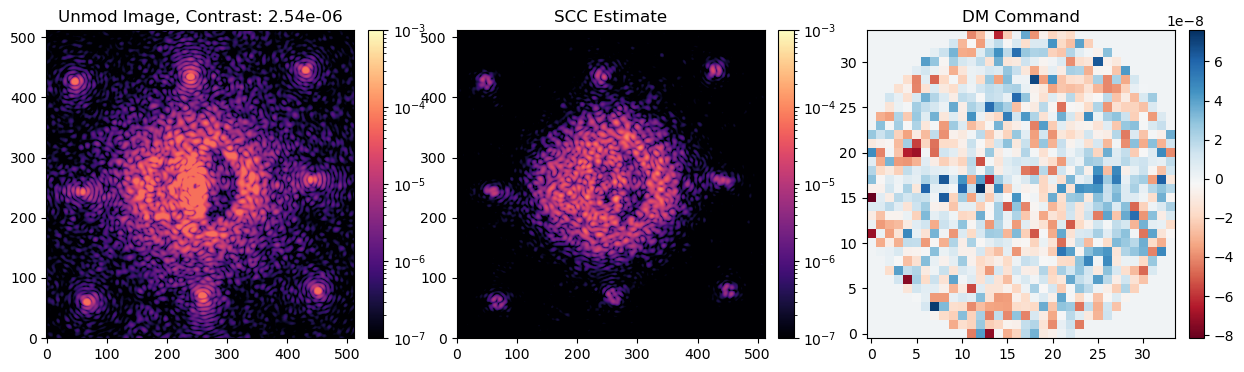

	Iteration 4 / 5
Pinhole is blocked, moving stagepiezo...
Taking modulated image...
Finished taking modulated image, moving stagepiezo...
Taking unmodulated image...


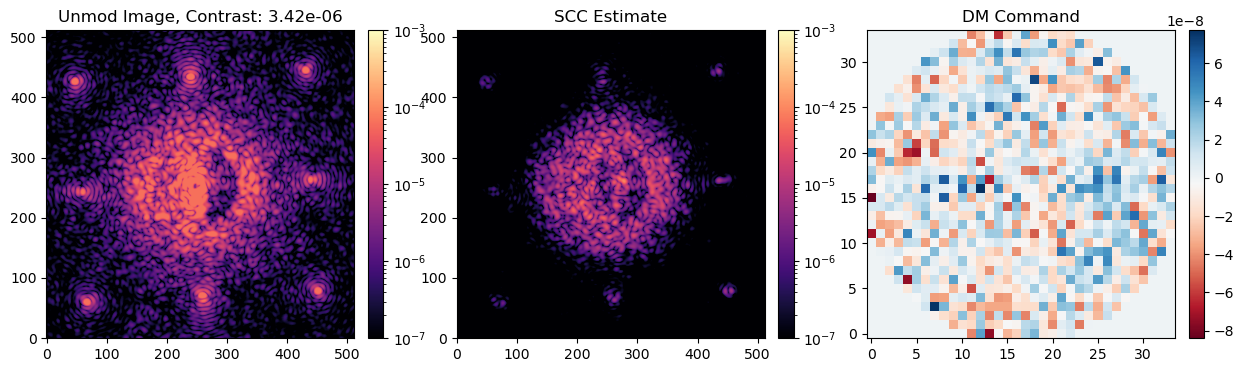

	Iteration 5 / 5
Pinhole is blocked, moving stagepiezo...
Taking modulated image...
Finished taking modulated image, moving stagepiezo...
Taking unmodulated image...


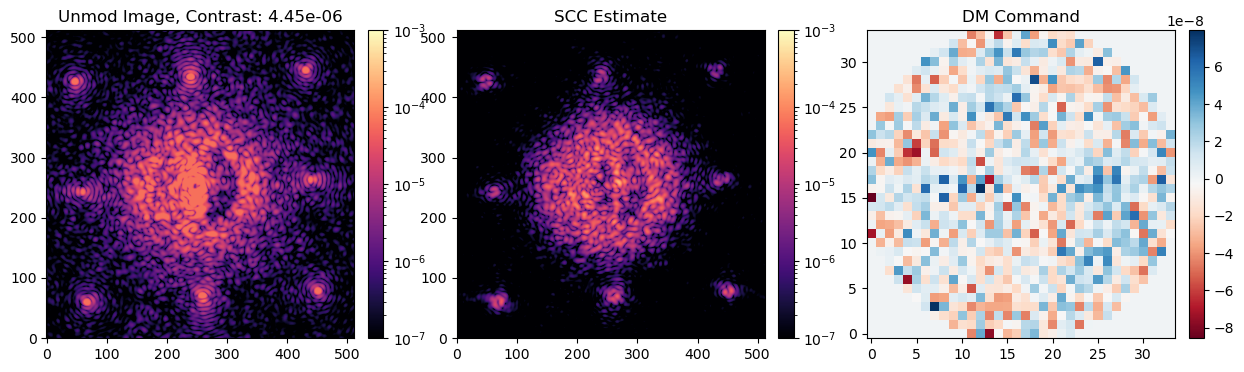

In [314]:
reload(utils)
reload(scc)

data = scc.run(data=data,
                INDIclient=client,
                camsci_stream=camsci_stream, 
                dm_stream=dm_ho_stream, 
                control_matrix=cm20,
                calibration_modes=dm_modes,
                control_mask=control_mask,
                scc_reference=None,
                shift=(8, 53),
                diam_window=0.17,
                im_params=im_params,
                ref_psf_params=ref_params, 
                dark_frame=dark_frame,
                NFRAMES=100, 
                delay=0.5,
                num_iterations=5,
                gain=0.75, 
                leakage=0.0)

Text(0.5, 1.0, 'Difference, RMS: 4.004095172344682e-06')

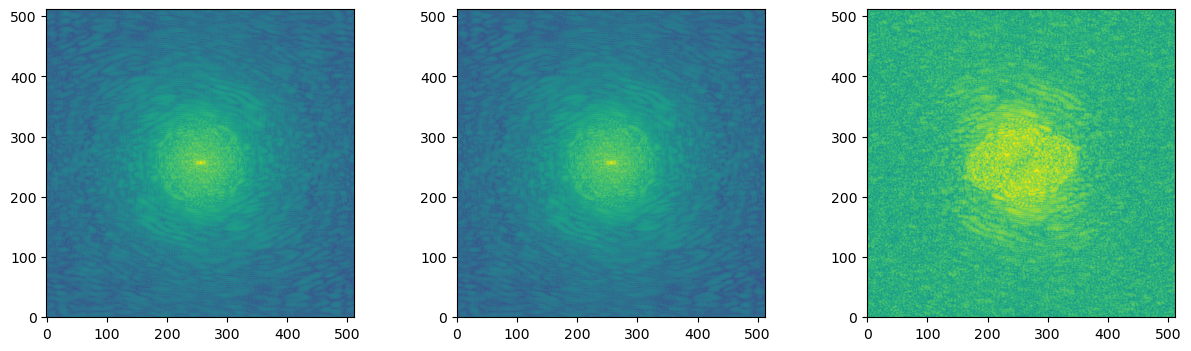

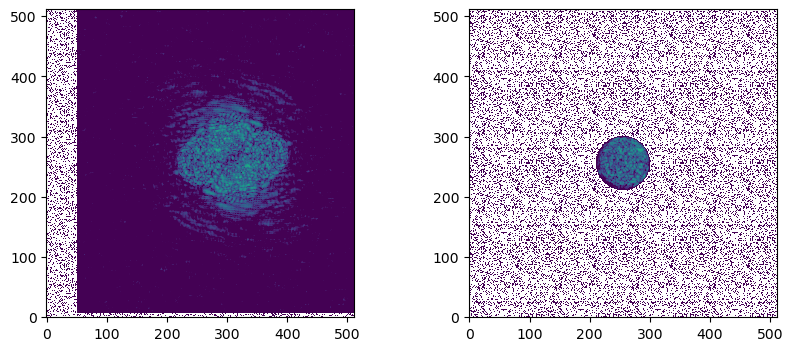

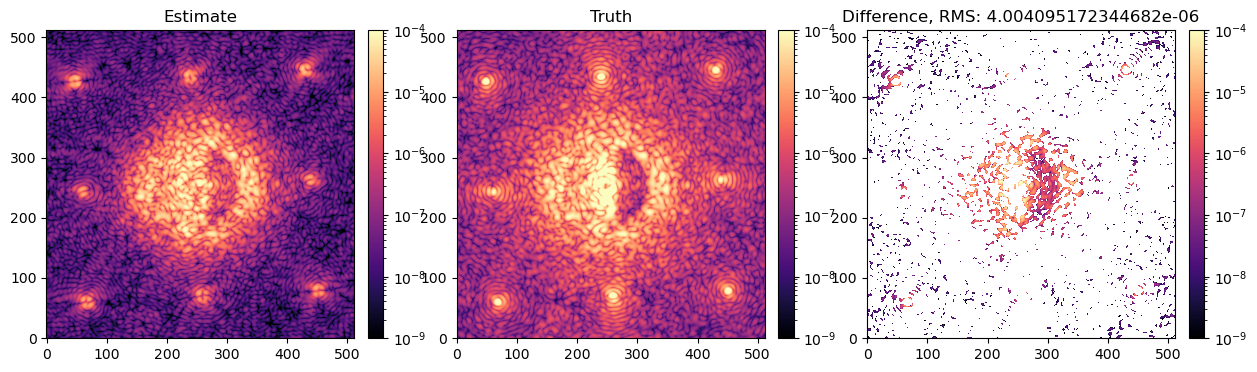

In [311]:
image_mod = xp.asarray(data['images_mod'][-1])
image_unmod = xp.asarray(data['images_unmod'][-1])

fft_mod = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(image_mod), norm='ortho'))
fft_unmod = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(image_unmod), norm='ortho'))
fft_diff = fft_mod - fft_unmod

fft_shifted = xcipy.ndimage.shift(fft_diff, (8, 53))

x, y = xp.meshgrid(xp.linspace(-1, 1, fft_shifted.shape[0]), xp.linspace(-1, 1, fft_shifted.shape[0]))
r = xp.sqrt(x ** 2 + y ** 2)
mask = r < 0.17

fft_masked = fft_shifted * mask

estimate = xp.fft.ifftshift(xp.fft.fft2(xp.fft.fftshift(fft_masked), norm='ortho'))

estimate *= np.sqrt(image_unmod.max()) / estimate.max()


plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(xp.abs(fft_mod).get(), norm='log')
plt.subplot(132)
plt.imshow(xp.abs(fft_unmod).get(), norm='log')
plt.subplot(133)
plt.imshow(xp.abs(fft_diff).get(), norm='log')


plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(xp.abs(fft_shifted).get(), norm='log', vmin=1e-7, vmax=5e-6)
plt.subplot(122)
plt.imshow(xp.abs(fft_masked).get(), norm='log', vmin=1e-7, vmax=5e-6)

diff = xp.abs(estimate).get() ** 2 - image_unmod.get()

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(xp.abs(estimate).get() ** 2, cmap='magma', norm='log', vmin=1e-9, vmax=1e-4)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Estimate')
plt.subplot(132)
plt.imshow(image_unmod.get(), cmap='magma', norm='log', vmin=1e-9, vmax=1e-4)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Truth')
plt.subplot(133)
plt.imshow(diff, cmap='magma', norm='log', vmin=1e-9, vmax=1e-4)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title(f'Difference, RMS: {np.sqrt(np.mean(diff[control_mask] ** 2))}')

In [315]:
utils.save_pickle(exp_path + '/dig01.pkl', data)

Saved data to:  /home/derbyk/src/scoob-scc/data_exp/20250610_scc_dig_mono/dig01.pkl


In [316]:
test = utils.load_pickle(exp_path + '/dig01.pkl')